In [1]:
!pip install sentence-transformers scikit-learn matplotlib seaborn -q

In [2]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [3]:
sentences = [
    # Cricket
    "The batsman scored a century in the final match.",
    "The bowler delivered a fast yorker to take the wicket.",
    "The cricket team won the series after a strong partnership.",
    "The captain set an attacking field during the powerplay.",

    # Cooking
    "The chef added fresh herbs to improve the flavor of the soup.",
    "Baking a cake requires careful measurement of flour and sugar.",
    "The pan should be heated before adding oil and vegetables.",

    # Cybersecurity
    "Strong passwords help protect accounts from unauthorized access.",
    "The company installed a firewall to block malicious traffic.",
    "Phishing emails often try to steal personal information."
]

In [5]:
model = SentenceTransformer("all-MiniLM-L6-v2")
embeddings = model.encode(sentences)
print("Embedding shape:", embeddings.shape)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedding shape: (10, 384)


In [6]:
similarity_matrix = cosine_similarity(embeddings, embeddings)

similarity_df = pd.DataFrame(
    similarity_matrix,
    index=[f"S{i+1}" for i in range(len(sentences))],
    columns=[f"S{i+1}" for i in range(len(sentences))]
)

similarity_df

,S1,S2,S3,S4,S5,S6,S7,S8,S9,S10
S1,1.000000,0.451499,0.517443,0.308705,-0.022781,0.067133,-0.019801,-0.050254,0.023707,-0.072225
S2,0.451499,1.000000,0.419766,0.286565,0.119139,0.092843,0.044620,0.015570,0.110526,0.020311
S3,0.517443,0.419766,1.000000,0.243450,0.034493,-0.008085,0.034109,0.065900,0.072440,-0.034077
S4,0.308705,0.286565,0.243450,1.000000,0.039793,-0.087164,0.066991,0.029321,0.145820,-0.024909
S5,-0.022781,0.119139,0.034493,0.039793,1.000000,-0.000094,0.280938,0.020488,0.108588,-0.041606
S6,0.067133,0.092843,-0.008085,-0.087164,-0.000094,1.000000,0.244769,0.004384,0.010185,0.086491
S7,-0.019801,0.044620,0.034109,0.066991,0.280938,0.244769,1.000000,-0.095285,0.120371,0.079287
S8,-0.050254,0.015570,0.065900,0.029321,0.020488,0.004384,-0.095285,1.000000,0.160310,0.411506
S9,0.023707,0.110526,0.072440,0.145820,0.108588,0.010185,0.120371,0.160310,1.000000,0.227273
S10,-0.072225,0.020311,-0.034077,-0.024909,-0.041606,0.086491,0.079287,0.411506,0.227273,1.000000


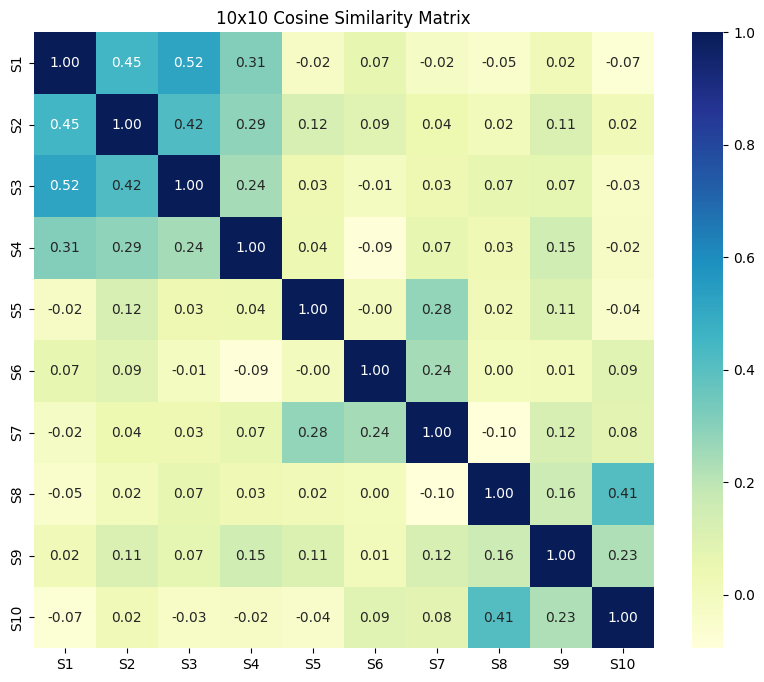

In [7]:
plt.figure(figsize=(10, 8))
sns.heatmap(similarity_df, annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("10x10 Cosine Similarity Matrix")
plt.show()